In [21]:
import numpy as np
import cupy as cp
from scipy.ndimage import convolve
from cupyx.scipy import ndimage
from tanalysis import improcess
import matplotlib.pyplot as plt
import skimage as sk
import tifffile as tiff
from skimage.measure import label, regionprops

In [2]:
def LoG(sigma):
    n = cp.ceil(sigma*6)
    z,y,x = cp.ogrid[-n//2:n//2+1, -n//2:n//2+1, -n//2:n//2+1]
    z_filter = cp.exp(-(z*z/2*sigma**2))
    y_filter = cp.exp(-(y*y/2*sigma**2))
    x_filter = cp.exp(-(x*x/2*sigma**2))
    final_filter = -(3/(sigma**5*(2*np.pi)**(3/2)))*(1-(x*x+y*y+z*z)/(3*sigma**2))*(z_filter*x_filter*y_filter)
    return final_filter

In [10]:
def LoG_convolve(img, sigma):
    filter_log = LoG(sigma)
    image = ndimage.convolve(img, filter_log)
    #image = cp.pad(image, ((1,1,1),(1,1,1)), 'constant')
    image = cp.square(image)
    return cp.asarray(image)

In [ ]:
def detect_blob(log_image_np, sigma):
    coords = []
    d,h,w = log_image_np.shape
    for i in range(6,h-5):
        for j in range(6,w-5):
            slice_img = log_image_np[:,i-6:i+7,j-6:j+7]
            result = cp.max(slice_img)
            if result>=150:
                z,x,y = cp.unravel_index(slice_img.argmax(), slice_img.shape)
                coords.append((i+x-1,j+y-1,sigma))
    return coords

In [4]:
dirname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.2.Test\EXP.HD6.1.2.Test.0\24h\Stitched\24h_chem10_thunder-0.tiff"
imgs, names, info = improcess.imread(dirname, False, False)

In [63]:
T,D,H,W = imgs[0].shape
result = np.empty(shape=(T,D,H,W), dtype=np.int8)
t=0
for img in imgs[0]:
    img = cp.array(img)
    log_image_np = LoG_convolve(img, 0.86)
    maximage1 = cp.max(log_image_np)
    res_img = log_image_np>maximage1*0.95
    kernel1 = cp.ones((5,5,5))
    kernel1[1:-1,1:-1,1:-1] = cp.zeros((3,3,3))
    kernel2 = cp.zeros((5,5,5))
    kernel2[1:-1,1:-1,1:-1] = cp.ones((3,3,3))
    res_img = ndimage.convolve(res_img, kernel2)
    res_img = ndimage.convolve(res_img, kernel2)
    res_img_np = cp.asnumpy(res_img)
    res_img_np = label(res_img_np)
    result[t] = res_img_np
    t += 1

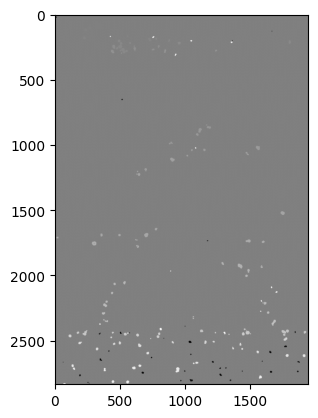

In [64]:
im = cp.asnumpy(result[6])

plt.figure()
plt.imshow(im[4], cmap='gray')
plt.show()

In [65]:
result_img = cp.asnumpy(result)
result_img = 255*np.uint8(result_img)
tiff.imwrite(r"C:\Users\pcanaleta\Desktop\Test\test.tiff", 
            result_img, 
            imagej=True,
            metadata={
                'axes':"TZYX"
            })